# Exercice 1 - Découvrez les blocs de construction de l'Apprentissage par Renforcement

In [1]:
import gymnasium as gym
import imageio
from IPython.display import Image
from PIL import Image as PILImage
from PIL import ImageDraw, ImageFont
import numpy as np

def add_text_to_frame(frame, n):
    # Convertir l'image numpy en PIL Image
    pil_img = PILImage.fromarray(frame)
    draw = ImageDraw.Draw(pil_img)
    font = ImageFont.load_default()

    # Ajouter le texte (numéro de l'étape)
    draw.text((10, 10), f"Step: {n}", fill="black", font=font)

    # Reconvertir en tableau numpy
    return np.array(pil_img)   
    

/usr/local/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


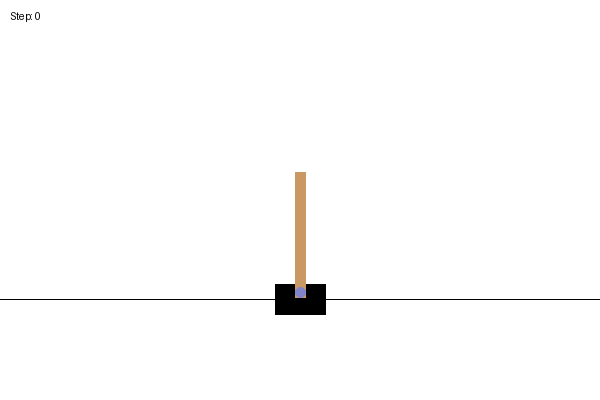

In [2]:
# Créer l'environnement
env = gym.make("CartPole-v1", render_mode="rgb_array")
observation, info = env.reset()

frames = []
step_number = 0

episode_over = False
while not episode_over:
    # Rendu de l'image
    frame = env.render()

    # Ajout du numéro d'étape dans l'image
    frames.append(add_text_to_frame(frame, step_number))

    # Avancer dans l'épisode
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    episode_over = terminated or truncated
    step_number += 1

env.close()

# Sauvegarder le GIF avec boucle infinie
gif_path = "cartpole_with_steps.gif"
imageio.mimsave(gif_path, frames, fps=5, loop=0)

# Afficher le GIF dans le notebook
Image(filename=gif_path)